# System 5: $V(r) = -10e^{-r^2}+1.5e^{-(r-2.0)^2/3.0^2}$, $s$-wave bound state, narrow $p$-wave resonance.
- Supports an $s$-wave bound state at $E_b=-1.268$.
- Supports a $p$-wave resonance at $E_r=1.8097-i0.1826$
    - $\phi_\text{min}=\text{arg}(E) / 2 \approx 0.05$.
    - $V(r)$ is a Gaussian, so $\phi_\text{max}=\pi/4\approx0.785$
- $\phi_\text{min} \le \phi < \phi_\text{max} = 0.0060 \le \phi < 0.785$.
- By $r=15$, $V(r=15)\propto 10^{-8} \approx 0$.

Due to finite volume effects, the good region of $\phi$ might vary from its theoretical value. This is a very narrow resonance. This gives
EC a much larger region to train over and a much smaller gap to extrapolate across for back-rotation.

In [1]:
from src.ecensemble import ECEnsemble
from src.ec import ECSystem
from src.dvr import DVR
from src.tikhonov import *
from src.utils import *

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
save_plots = True
plots_folder = get_plots_path() / "system_5"
plots_folder.mkdir(exist_ok=True, parents=True)

In [2]:
n = 256
L = 50.0
phi_stable = 0.35
real_res = 1.8097046 - 1j*0.1826095    #1.284 - 1j*0.0155
real_bound = -1.26798 + 1j*0.0         #-2.240 + 1j*0.0
real_telem = 0.926674 - 1j*0.113327

V_0, R = 10.0, 1.0
r_b, w, V_b = 2.0, 3.0, 1.5
def gauss_barrier(r):
    att_gauss = -V_0 * np.exp(-r**2/R**2)
    extra_barr = V_b * np.exp(-(r-r_b)**2/w**2)
    return att_gauss + extra_barr

In [3]:
sbound_system = DVR(n, L, rotation_angle=0.0, potential=gauss_barrier, l=0)
pres_system = DVR(n, L, rotation_angle=phi_stable, potential=gauss_barrier, l=1)

### Plot the good region of $\phi$ for system 4

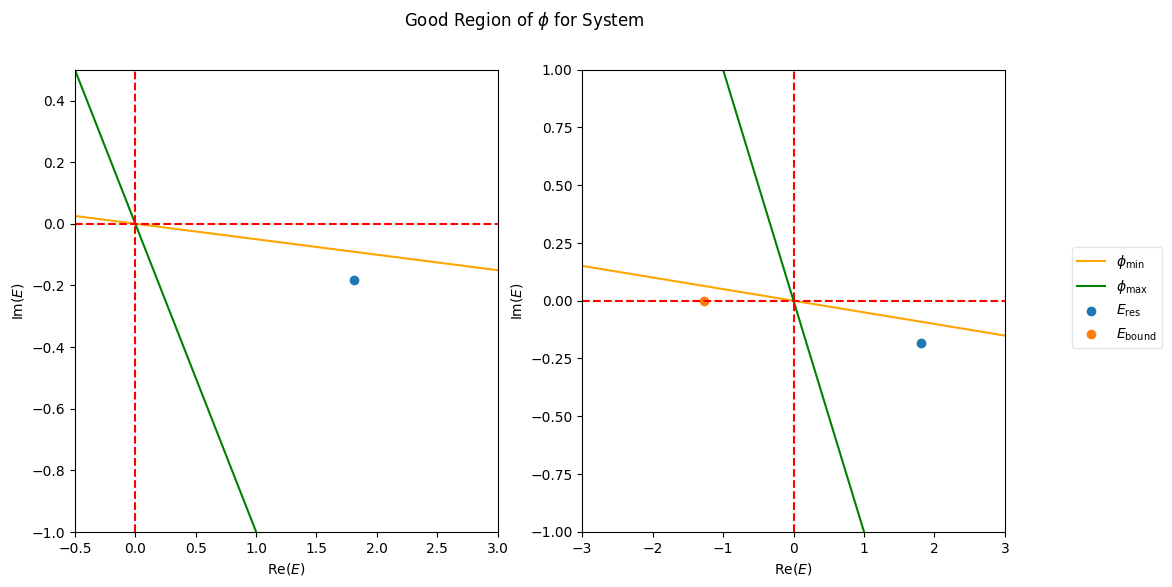

In [4]:
fig, (axres, axbound) = plt.subplots(1, 2, figsize=(12,6))
axres.set_xlim([-.5, 3.0])
axres.set_ylim([-1.0, 0.5])
axbound.set_xlim([-3.0, 3])
axbound.set_ylim([-1.0, 1.0])
for ax in (axres, axbound):
    ax.axline((0,0), (1, np.angle(real_res)/2), color='orange', label=r'$\phi_\text{min}$')
    ax.axline((0,0), (1, -np.tan(np.pi/4)), color='green', label=r'$\phi_\text{max}$')
    ax.axvline(0, linestyle='--', color='red')
    ax.axhline(0, linestyle='--', color='red')
    ax.scatter(np.real(real_res), np.imag(real_res), label=r'$E_\text{res}$')
    ax.set_xlabel(r"Re$(E)$")
    ax.set_ylabel(r"Im$(E)$")
    ax.legend().remove()
axbound.scatter(np.real(real_bound), np.imag(real_bound), label=r'$E_\text{bound}$')
fig.suptitle(r"Good Region of $\phi$ for System ")
handles, labels = axbound.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.95, 0.5), framealpha=0.5)
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "phi_good_region.png")
plt.show()

### $E(L)$, $(r_\theta^2)(L)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $\phi$.

In [5]:
# compute <r^2> as L varies
Ls = np.linspace(20.0, 70., 100)
energies, rrs, telems = [], [], []

for L in Ls:
    tbound = DVR(n, L, rotation_angle=phi_stable, potential=gauss_barrier, l=0)
    tres = DVR(n, L, rotation_angle=phi_stable, potential=gauss_barrier, l=1)

    b_energy, b_state = tbound.closest_to_resonance(real_bound)
    r_energy, r_state = tres.closest_to_resonance(real_res)
    
    rr = tres.compute_rr(r_state[:, 0], rotate_rr=True)
    telem = DVR.compute_transition_mat_element(L, b_state[:, 0], r_state[:, 0], rotation_angle=phi_stable, operator="E1")

    telems.append(telem)
    energies.append(r_energy[0])
    rrs.append(rr)

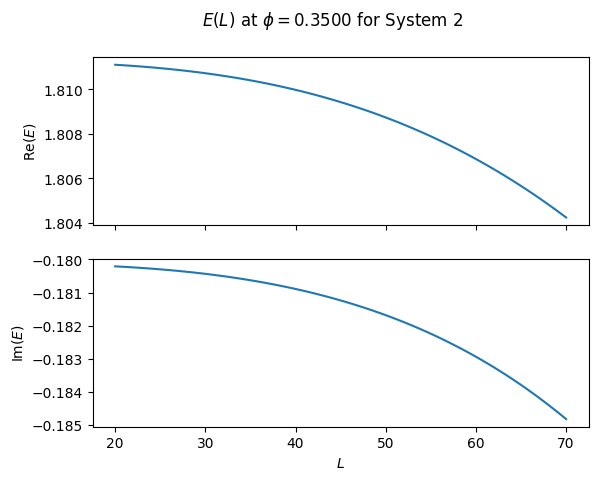

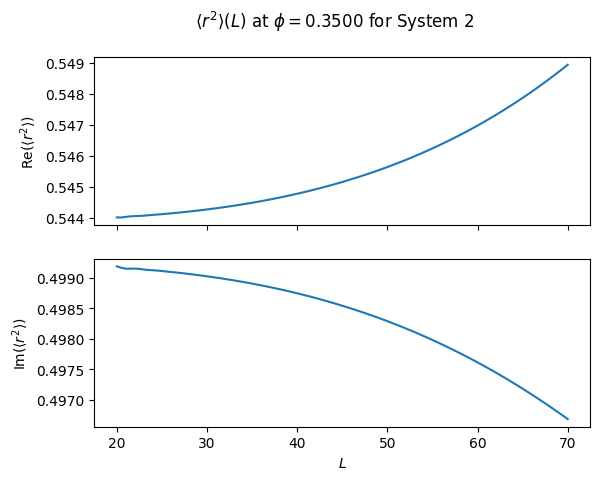

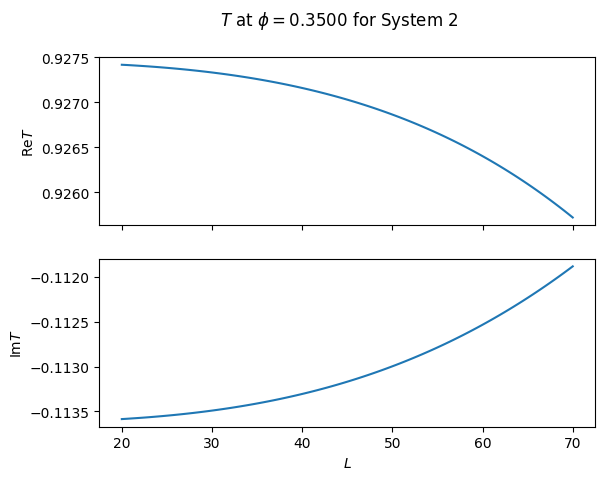

In [6]:
# plot E(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(energies))
ax2.plot(Ls, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$E(L)$ at $\phi=${phi_stable:.4f} for System 5")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_L.png")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(rrs))
ax2.plot(Ls, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$\langle r^2\rangle(L)$ at $\phi=${phi_stable:.4f} for System 5")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_L.png")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(telems))
ax2.plot(Ls, np.imag(telems))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $\phi=${phi_stable:.4f} for System 5")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_L.png")
plt.show()

### $E(\phi)$, $(r^2)(\theta)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $L$.

In [7]:
# compute E and <r^2> as phi varies
# the ABC theorem says that this should be const.
phis = np.linspace(0.25, 0.75, 100)
energies, rrs, telems = [], [], []

for phi in phis:
    sbound_system.reset_rotation_angle(phi)
    pres_system.reset_rotation_angle(phi)
    
    b_energy, b_state = sbound_system.closest_to_resonance(real_bound)
    r_energy, r_state = pres_system.closest_to_resonance(real_res)
    
    rr = pres_system.compute_rr(r_state[:, 0], rotate_rr=True)
    telem = DVR.compute_transition_mat_element(L, b_state[:, 0], r_state[:, 0], rotation_angle=phi, operator="E1")

    telems.append(telem)
    energies.append(r_energy[0])
    rrs.append(rr)

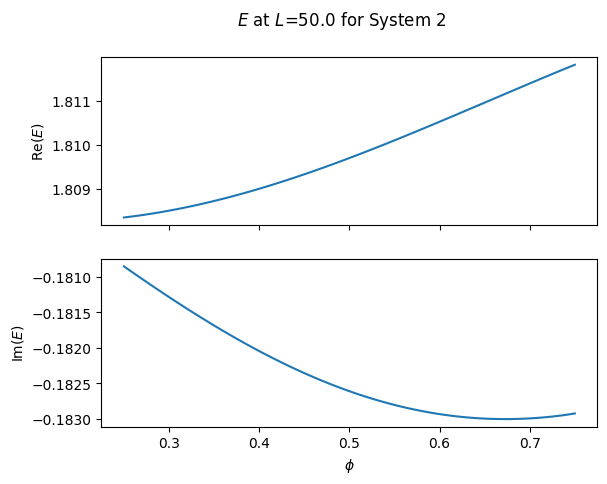

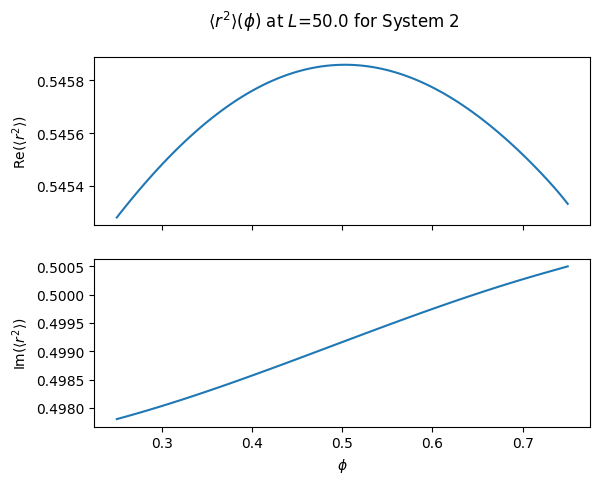

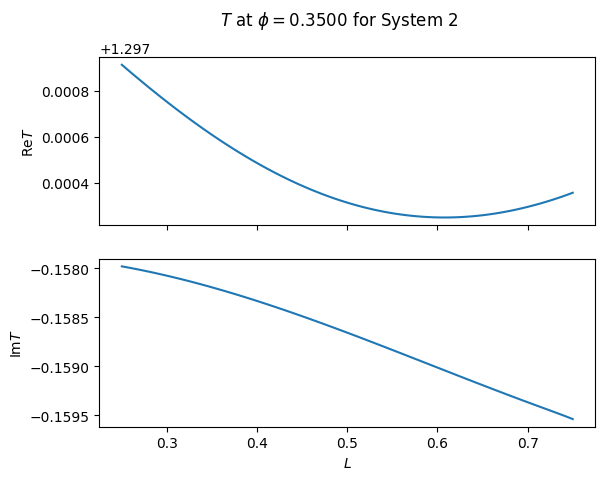

In [8]:
# plot <E>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(energies))
ax2.plot(phis, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$E$ at $L$=50.0 for System 5")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_phi.png")
plt.show()

# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(rrs))
ax2.plot(phis, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$\langle r^2\rangle(\phi)$ at $L$=50.0 for System 5")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_phi.png")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(telems))
ax2.plot(phis, np.imag(telems))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $\phi=${phi_stable:.4f} for System 5")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_phi.png")
plt.show()

### Using EC to predict $(r^2)$, $E$, and $(\psi_\text{res}|r|\psi_\text{bound})$.
The good region seems to be about $\phi\in [0.25, 0.75]$.


In [9]:
# define function to quickly check bound / resonance energy, transition matrix element, and residuals using EC
L = 50.0
def quick_predict(phi_predict, ec_system):
    # get bound state (no need to use EC here). This shouldn't change at all
    sbound_system.reset_rotation_angle(phi_predict)
    energies, states = sbound_system.closest_to_resonance(resonance=real_bound)
    bound_energy, bound_state = energies[0], states[:, 0]
    resid = np.abs(real_bound.real - bound_energy.real) + 1j*np.abs(real_bound.imag - bound_energy.imag)
    print(f"Bound state energy at phi={phi_predict}: {bound_energy.real:.4f} + i{bound_energy.imag:.4f}")
    print(f"\t Residual: {resid.real:.4f} + i{resid.imag:.4f}")
    
    # get predicted resonance using EC
    energy, backrot_prediction = ec_system.predict_DVR_state_at(phi_predict)
    resid = np.abs(real_res.real - energy.real) + 1j*np.abs(real_res.imag - energy.imag)
    print(f"Resonance energy prediction at phi={phi_predict:.4f}: {energy.real:.4f} + i{energy.imag:.4f}")
    print(f"\t Residual: {resid.real:.4f} + i{resid.imag:.4f}")
    
    # get trans element
    trans_elem = DVR.compute_transition_mat_element(L, bound_state, backrot_prediction, rotation_angle=phi_predict, operator="E1")
    trans_elem *= np.sign(trans_elem.real) # trans elem fixed to arbitrary +- 1; we choose positive real part
    resid = np.abs(real_telem.real - trans_elem.real) + 1j*np.abs(real_telem.imag - trans_elem.imag)
    print(f"Transition matrix element prediction at phi={phi_predict:.4f}: {trans_elem.real:.4f} + i{trans_elem.imag:.4f}")
    print(f"\t Residual: {resid.real:.4f} + i{resid.imag:.4f}")
    return energy, trans_elem

def get_training_data(phi_train):
    bound_energies = []
    training_energies, training_rrs, training_telems = [], [], []
    for phi in phi_train:
        sbound_system.reset_rotation_angle(phi)
        pres_system.reset_rotation_angle(phi)

        b_energy, bound_state = sbound_system.closest_to_resonance(real_bound)
        bound_state = bound_state[:, 0]
        bound_energies.append(b_energy[0])

        energy, res_state = pres_system.closest_to_resonance(real_res)
        energy, res_state = energy[0], res_state[:, 0]
        rr = pres_system.compute_rr(res_state, rotate_rr=True)
        
        telem = DVR.compute_transition_mat_element(L, bound_state, res_state, rotation_angle=phi, operator="E1")
        telem *= np.sign(np.real(telem))

        training_energies.append(energy)
        training_rrs.append(rr)
        training_telems.append(telem)
    training_energies = np.array(training_energies)
    training_rrs = np.array(training_rrs)
    training_telems = np.array(training_telems)
    bound_energies = np.array(bound_energies)

    print(
        f"Training bound energy: ({np.median(np.real(bound_energies))} +- {np.std(np.real(bound_energies))})"
        f" + i({np.median(np.imag(bound_energies))} +- {np.std(np.imag(bound_energies))})"
    )
    print(
        f"Training resonance energy: ({np.median(np.real(training_energies))} +- {np.std(np.real(training_energies))})"
        f" + i({np.median(np.imag(training_energies))} +- {np.std(np.imag(training_energies))})"
    )
    print(
        f"Training <r^2>: ({np.median(np.real(training_rrs))} +- {np.std(np.real(training_rrs))})"
        f" + i({np.median(np.imag(training_rrs))} +- {np.std(np.imag(training_rrs))})"
    )
    print(
        f"Training telems: ({np.median(np.real(training_telems))} +- {np.std(np.real(training_telems))})"
        f" + i({np.median(np.imag(training_telems))} +- {np.std(np.imag(training_telems))})"
    )
    return training_energies, training_rrs, training_telems

In [10]:
num_training_points = 20
phi_train = np.linspace(0.25, 0.75, 20)

# get training data
training_energies, training_rrs, training_telems = get_training_data(phi_train)

Training bound energy: (-1.2679835823890455 +- 1.8276543415898294e-05) + i(3.220259740251053e-05 +- 1.0788256511216362e-05)
Training resonance energy: (1.8097046041869191 +- 0.001101080589224328) + i(-0.18260951565398204 +- 0.0006908768320828025)
Training <r^2>: (0.5457007424682037 +- 0.00018232628408386612) + i(0.49916109811492365 +- 0.000847261272468345)
Training telems: (0.9266741305271744 +- 0.0001446437595179923) + i(-0.11332685560726921 +- 0.00035041164546321957)


In [11]:
# train EC
ecsystem = ECSystem(pres_system, real_res)
print("Training...")
ecsystem.train(phi_train)
training_eigvals = ecsystem.training_eigvals
print("Training complete.")
ecsystem.construct_basis()
print("Basis constructed.")

Training...
Training complete.
Basis constructed.


#### Interpolation to $\phi=0.35$

In [12]:
phi_predict = phi_stable
_, _ = quick_predict(phi_predict, ecsystem)

Bound state energy at phi=0.35: -1.2680 + i0.0000
	 Residual: 0.0000 + i0.0000
Resonance energy prediction at phi=0.3500: 1.8087 + i-0.1817
	 Residual: 0.0010 + i0.0009
Transition matrix element prediction at phi=0.3500: 0.9269 + i-0.1130
	 Residual: 0.0002 + i0.0003


#### Extrapolation to $\phi=0$.

In [13]:
phi_predict = 0.0
_, _ = quick_predict(phi_predict, ecsystem)

Bound state energy at phi=0.0: -1.2679 + i0.0000
	 Residual: 0.0001 + i0.0000
Resonance energy prediction at phi=0.0000: 1.8090 + i-0.1789
	 Residual: 0.0007 + i0.0037
Transition matrix element prediction at phi=0.0000: 0.9096 + i-0.1004
	 Residual: 0.0171 + i0.0129


### EC w stats to measure states as number of training points changes.

In [ ]:
phi_predict = 0.0
n = 256
L = 50.0
n_ecsystems = 128

sbound_system.reset_rotation_angle(phi_predict)
pres_system.reset_rotation_angle(phi_predict)

_, bound_state = sbound_system.closest_to_resonance(real_bound)
bound_state = bound_state[:, 0]

phi_training_range, num_phi_points_list = [0.25, 0.75], [3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75]
ecensemble = ECEnsemble(n_ecsystems, pres_system, real_res)

# train EC ensembles for multiple training points
all_energy_stats, all_telems_stats = [], []
all_energy_resid_stats, all_telems_resid_stats = [], []
all_rr_stats, all_rr_resid_stats = [], []
for num_phi_points in num_phi_points_list:
    print(f"Training EC on {num_phi_points} training points.")
    ecensemble.train(phi_training_range, num_phi_points)
    ecensemble.construct_bases()
    energies, dvr_states = ecensemble.predict_DVR_states_at(phi_predict)
    telems = np.array([
        DVR.compute_transition_mat_element(
            L, bound_state, dvr_state, rotation_angle=phi_predict, operator="E1"
        ) for dvr_state in dvr_states.T
    ])

    rrs = np.array([pres_system.compute_rr(dvr_state, rotate_rr=True) for dvr_state in dvr_states.T])
    rr_stats = ECEnsemble.compute_stats(rrs)
    rr_resid_stats = ECEnsemble.compute_resid_stats(real_rr, rrs)
    
    energy_stats = ECEnsemble.compute_stats(energies)
    energy_resid_stats = ECEnsemble.compute_resid_stats(real_res, energies)

    # phase align telems first before taking stats
    telems *= np.sign(np.real(telems))
    telems_stats = ECEnsemble.compute_stats(telems)
    telems_resid_stats = ECEnsemble.compute_resid_stats(real_telem, telems)

    all_energy_stats.append(energy_stats)
    all_energy_resid_stats.append(energy_resid_stats)

    all_telems_stats.append(telems_stats)
    all_telems_resid_stats.append(telems_resid_stats)
    ecensemble.clear_all()

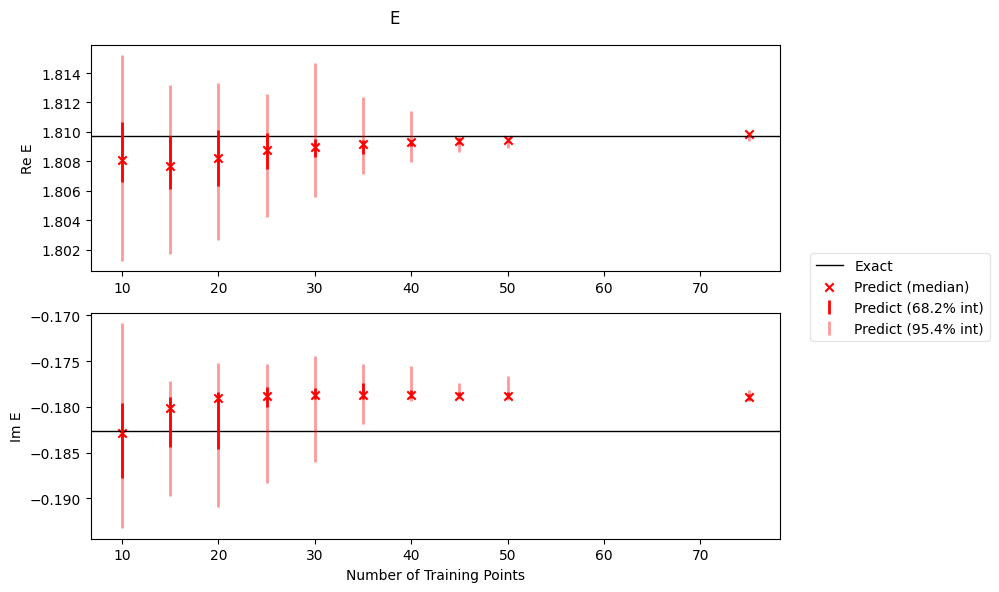

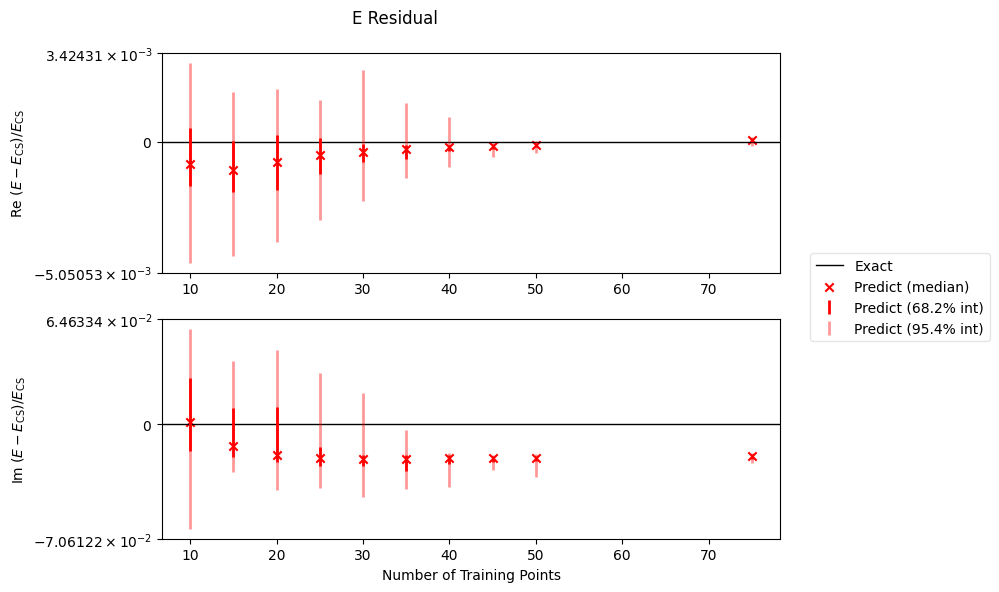

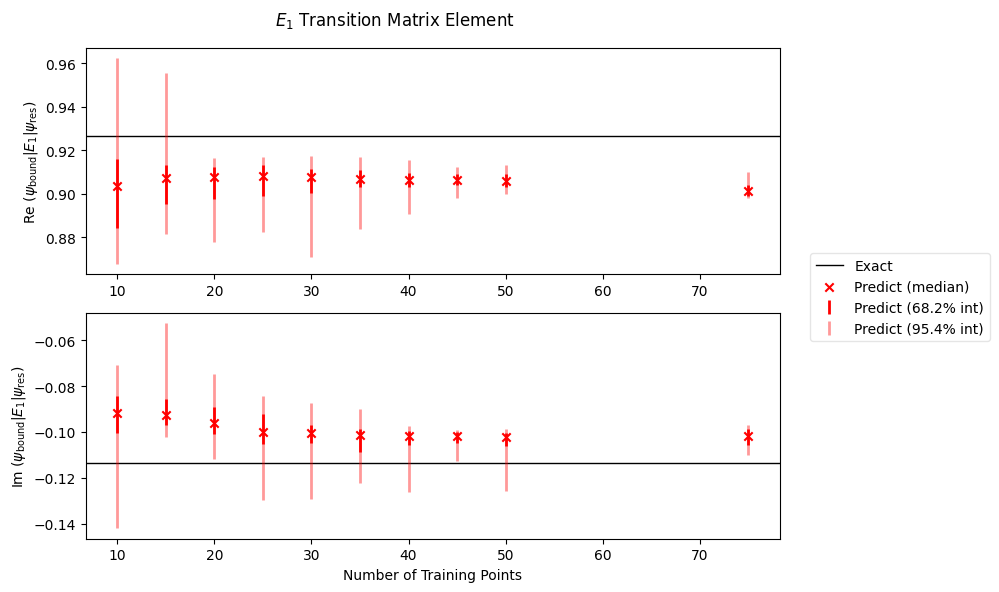

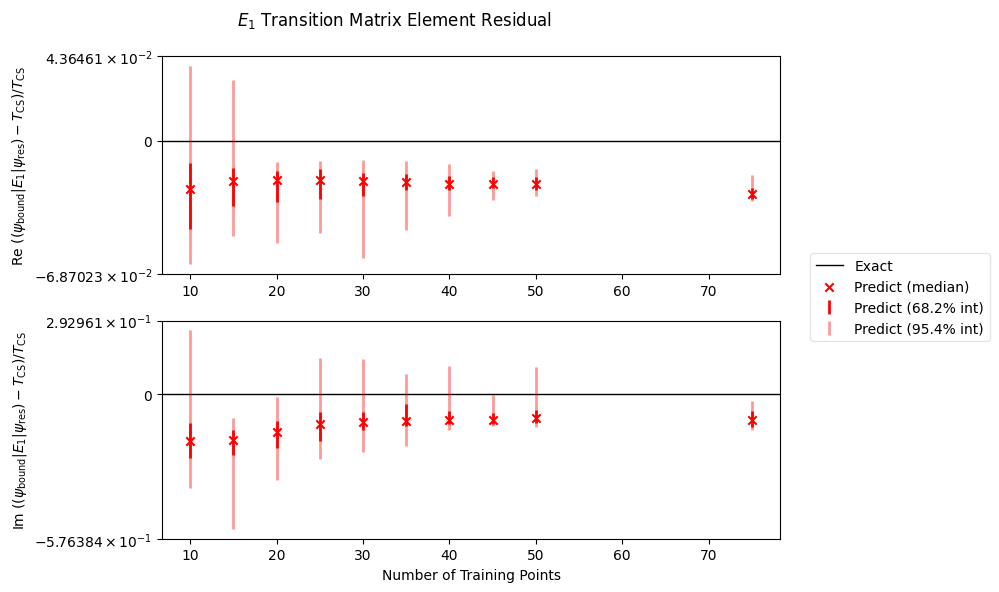

In [15]:
def plot(fig, ax, exact, xs, data, **kwargs):
    axreal, aximag = ax
    # get stats from data
    med, err68, err95 = decompose_stats(data)

    # get plot kwargs
    title = kwargs.get("title", "")
    ylabel = kwargs.get("ylabel", "")
    xlabel = kwargs.get("xlabel", "")
    scale = kwargs.get("scale", "linear")
    cutoff = kwargs.get("cutoff", 0)
    color = kwargs.get("color", "red")

    # plot real and imaginary components
    axreal.axhline(y=np.real(exact), color='black', linewidth=1.0, linestyle='-', label='Exact')
    aximag.axhline(y=np.imag(exact), color='black', linewidth=1.0, linestyle='-', label='Exact')
    plot_stats(fig, (axreal, aximag), xs, med, err68, err95, cutoff=cutoff, color=color)

    # set labels, title, and legend
    axreal.set_ylabel(f"Re {ylabel}")
    aximag.set_ylabel(f"Im {ylabel}")
    aximag.set_xlabel(xlabel)
    #axreal.set_xlabel(xlabel)
    if scale=="symlog":
        axreal.set_yscale(scale, linthresh=1e-4)
        aximag.set_yscale(scale, linthresh=1e-4)
    else:
        axreal.set_yscale(scale)
        aximag.set_yscale(scale)
    fig.suptitle(f"{title}")

    handles, labels = axreal.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), framealpha=0.5)
    axreal.legend().remove()
    aximag.legend().remove()
    return fig, (axreal, aximag)
    
# Plot energy and energy residuals
figsize=(8, 6)
cutoff=2
fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": "E", "xlabel": r"Number of Training Points", "title": "E", "cutoff": cutoff}
_ = plot(fig, (axreal, aximag), real_res, num_phi_points_list, all_energy_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system5_ec_backrotated_E_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$(E - E_\text{CS})/E_\text{CS}$", "cutoff": cutoff, "xlabel": r"Number of Training Points", "title": "E Residual", "scale": "symlog"}
_ = plot(fig, (axreal, aximag), 0.0+1j*0.0, num_phi_points_list, all_energy_resid_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system5_ec_backrotated_Eresid_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$(\psi_\text{bound}|E_1|\psi_\text{res})$", "xlabel": 
               r"Number of Training Points", "cutoff": cutoff, "title": r"$E_1$ Transition Matrix Element"}
_ = plot(fig, (axreal, aximag), real_telem, num_phi_points_list, all_telems_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system5_ec_backrotated_telem_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$((\psi_\text{bound}|E_1|\psi_\text{res})-T_\text{CS})/T_\text{CS}$", "cutoff": cutoff,
               "xlabel": r"Number of Training Points", "title": r"$E_1$ Transition Matrix Element Residual", "scale": "symlog"}
_ = plot(fig, (axreal, aximag), 0.0, num_phi_points_list, all_telems_resid_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system5_ec_backrotated_telem_resid_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"(r^2)", "xlabel": r"Number of Training Points", "title": "(r^2)", "cutoff": cutoff}
_ = plot(fig, (axreal, aximag), real_res, num_phi_points_list, all_energy_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system5_ec_backrotated_rr_wrt_trainingpoints.png")
plt.show()

fig, (axreal, aximag) = plt.subplots(2, 1, figsize=figsize)
plot_kwargs = {"ylabel": r"$((r^2) - r^2_\text{CS})/(r^2)_\text{CS}$", "cutoff": cutoff, "xlabel": r"Number of Training Points", "title": r"(r^2) Residual", "scale": "symlog"}
_ = plot(fig, (axreal, aximag), 0.0+1j*0.0, num_phi_points_list, all_energy_resid_stats, **plot_kwargs)
plt.tight_layout()
if save_plots: fig.savefig(plots_folder / "system5_ec_backrotated_rr_resid_wrt_trainingpoints.png")
plt.show()

### Tikhonov Comparison

In [16]:
# get rotated state at a good phi value
phi_predict = 0.4
sbound_system.reset_rotation_angle(phi_predict)
pres_system.reset_rotation_angle(phi_predict)

bound_state = sbound_system.closest_to_resonance(real_bound)[1][:, 0]
res_state = pres_system.closest_to_resonance(real_res)[1][:, 0]

In [17]:
# basic Tikhonov setup
tikhonov_sys = Tikhonov(n, L, N=1024, xmax=15.0)
xs = tikhonov_sys.x
dx = xs[1] - xs[0]
r_log = tikhonov_sys.r_log # the Jacobian, |dr/dx|
func = tikhonov_sys.dvrstate_on_logmesh(bound_state)*r_log*tikhonov_sys.dvrstate_on_logmesh(res_state)
xis, fft = tikhonov_sys.compute_fft(func)
back_xis, back_fft = tikhonov_sys.backrotated_fft(func, phi_predict)

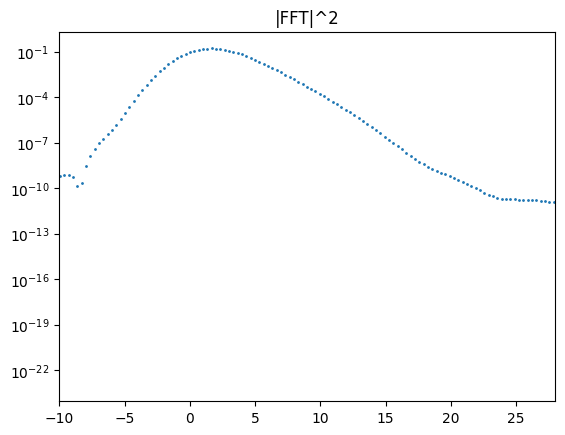

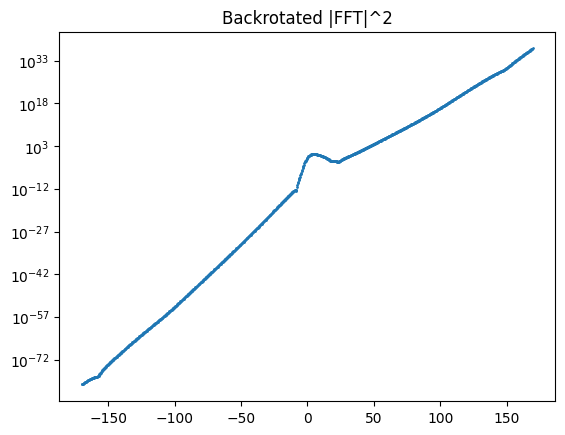

In [18]:
# plot frequency spectrum of fft and backrotated fft
fig, ax = plt.subplots()
ax.scatter(xis, np.real(np.conj(fft).T*fft), s=1)
ax.set_title("|FFT|^2")
ax.set_xlim([-10, 28])
ax.set_yscale("log")
plt.show()

# plot frequency spectrum of fft and backrotated fft
fig, ax = plt.subplots()
ax.scatter(back_xis, np.real(np.conj(back_fft).T*back_fft), s=1)
ax.set_title("Backrotated |FFT|^2")
#ax.set_xlim([-10, 20])
ax.set_yscale("log")
plt.show()

In [19]:
# use sigmoid with varying widths to compute bound state norm
widths = np.logspace(-7.0, 3, 50)
norms = []
for width in widths:
    f_reg = tikhonov_sys.apply_tikhonov_filter(phi_predict, xis, fft, Tikhonov.high_pass, width)
    norms.append(np.abs(np.real(np.sum(f_reg * r_log)*dx)))

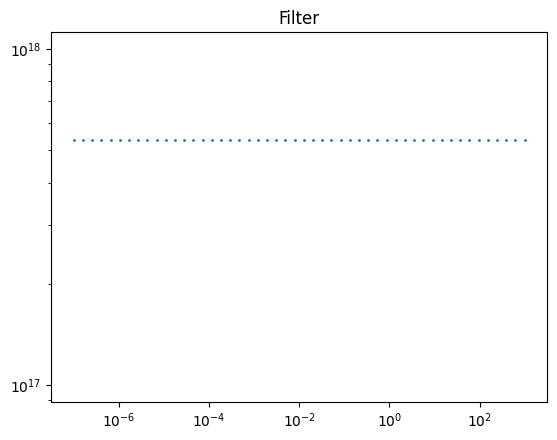

In [20]:
# plot bound state norm over varying frequencies for various widths
fig, ax = plt.subplots()
ax.scatter(widths, norms, s=1)
ax.set_xscale('log')
ax.set_yscale("log")
ax.set_title("Filter")
plt.show()

In [21]:
# use sigmoid at constant width (w=1.0) with varying xi_minus and xi_plus
xi_minus = np.linspace(-10, -30, 55)
xi_plus = np.linspace(25, 45, 55)
width = 1.0

norms = []
for xim in xi_minus:
    norms_p = []
    for xip in xi_plus:
        sigmoid_filter = Tikhonov.high_pass(xim, xip, width)
        f_reg = tikhonov_sys.apply_tikhonov_filter(phi_predict, xis, fft, sigmoid_filter)
        norm = np.sum(f_reg * r_log)*dx
        norms_p.append(norm)
    norms.append(norms_p)
norms = np.array(norms)

TypeError: 'numpy.float64' object is not callable

In [ ]:
# plot bound state norm over varying frequencies for various widths
fig, ax = plt.subplots()
ax.scatter(xi_minus, norms[:, 0], s=5)
ax.set_title("xi minus")
plt.show()

# plot bound state norm over varying frequencies for various widths
fig, ax = plt.subplots()
ax.scatter(xi_plus, norms[0, :], s=5)
ax.set_title("xi plus")
plt.show()

In [ ]:
# use Tikhonov filter with xi_minus = -25 and xi_plus = 25